# Homework 1: Data Analysis
# Air Quality Index Dataset Analysis

**IEEE Conference Paper Format**

This notebook follows the IEEE paper structure:
- Abstract
- Introduction
- Methods
- Results

## Abstract

*To be completed: Provide a short and informative overview of your data analysis work, including main objectives, methods used, and key findings from the Air Quality dataset.*

## 1. Introduction

*To be completed:*
- *Importance of air quality monitoring*
- *Brief literature review on air quality analysis*
- *Dataset description and motivation*
- *Research questions*

## 2. Methods

This section describes the data analysis methods used in this study.

### 2.1 Setup and Imports

In [10]:
# Standard libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# Custom database module
import sys
sys.path.append('..')

# Carrega o dataset 
df = pd.read_csv("../database/air_quality_uci.csv", sep=";", decimal=",", parse_dates=[['Date', 'Time']], na_values=-200)  



# Display settings
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)
%matplotlib inline

print("Dimensões:", df.shape)  # linhas e colunas
print("Valores nulos por coluna:\n", df.isna().sum())


Dimensões: (9471, 16)
Valores nulos por coluna:
 Date_Time           0
CO(GT)           1797
PT08.S1(CO)       480
NMHC(GT)         8557
C6H6(GT)          480
PT08.S2(NMHC)     480
NOx(GT)          1753
PT08.S3(NOx)      480
NO2(GT)          1756
PT08.S4(NO2)      480
PT08.S5(O3)       480
T                 480
RH                480
AH                480
Unnamed: 15      9471
Unnamed: 16      9471
dtype: int64


C:\Users\picol\AppData\Local\Temp\ipykernel_2328\4128530208.py:13: FutureWarning: Support for nested sequences for 'parse_dates' in pd.read_csv is deprecated. Combine the desired columns with pd.to_datetime after parsing instead.
  df = pd.read_csv("../database/air_quality_uci.csv", sep=";", decimal=",", parse_dates=[['Date', 'Time']], na_values=-200)
C:\Users\picol\AppData\Local\Temp\ipykernel_2328\4128530208.py:13: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df = pd.read_csv("../database/air_quality_uci.csv", sep=";", decimal=",", parse_dates=[['Date', 'Time']], na_values=-200)


### 2.2 Data Loading

In [11]:
# Initialize data loader
df = pd.read_csv("../database/air_quality_uci.csv", sep=";", decimal=",", na_values=-200)

#testando
# Load Air Quality dataset
# Note: The UCI Air Quality dataset typically uses ';' as separator and ',' as decimal
# df = loader.load_csv('AirQualityUCI.csv', sep=';', decimal=',')

# For demonstration, we'll create a sample structure similar to the Air Quality dataset
# Replace this with actual data loading
np.random.seed(42)
n_samples = 9358
df = pd.DataFrame({
    'Date': pd.date_range('2004-03-10', periods=n_samples, freq='H'),
    'CO(GT)': np.random.uniform(0.5, 5.0, n_samples),
    'PT08.S1(CO)': np.random.uniform(800, 1600, n_samples),
    'NMHC(GT)': np.random.uniform(50, 250, n_samples),
    'C6H6(GT)': np.random.uniform(2, 20, n_samples),
    'PT08.S2(NMHC)': np.random.uniform(600, 1400, n_samples),
    'NOx(GT)': np.random.uniform(50, 300, n_samples),
    'PT08.S3(NOx)': np.random.uniform(400, 1200, n_samples),
    'NO2(GT)': np.random.uniform(20, 150, n_samples),
    'PT08.S4(NO2)': np.random.uniform(800, 1800, n_samples),
    'PT08.S5(O3)': np.random.uniform(600, 1600, n_samples),
    'T': np.random.uniform(5, 35, n_samples),
    'RH': np.random.uniform(20, 80, n_samples),
    'AH': np.random.uniform(0.3, 1.8, n_samples)
})

print(f"Dataset shape: {df.shape}")
print(f"\nFirst few rows:")
df.head()

Dataset shape: (9358, 14)

First few rows:


C:\Users\picol\AppData\Local\Temp\ipykernel_2328\3683400066.py:14: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  'Date': pd.date_range('2004-03-10', periods=n_samples, freq='H'),


,Date,CO(GT),PT08.S1(CO),NMHC(GT),C6H6(GT),PT08.S2(NMHC),NOx(GT),PT08.S3(NOx),NO2(GT),PT08.S4(NO2),PT08.S5(O3),T,RH,AH
0,2004-03-10 00:00:00,2.185431,1483.476786,157.099943,15.689565,824.935425,139.396035,1003.287469,108.816761,1646.752702,1122.478483,25.898709,42.333922,1.274936
1,2004-03-10 01:00:00,4.778214,1349.414236,53.287212,11.447270,670.419223,240.014384,788.315706,118.329566,1367.981355,652.612006,28.264700,46.536724,0.346535
2,2004-03-10 02:00:00,3.793973,1216.066147,100.262592,3.250407,1004.041304,75.136090,440.002718,129.107268,1738.586795,1483.490068,31.092979,63.948706,1.144313
3,2004-03-10 03:00:00,3.193963,1464.200154,234.351049,7.870007,1051.588589,218.025216,553.292542,81.431122,946.896852,740.370760,5.092935,71.920585,0.391486
4,2004-03-10 04:00:00,1.202084,1135.399399,235.212275,3.574760,962.072020,272.440815,639.022740,93.715747,826.017980,876.196258,10.291975,77.628219,1.571858


### 2.3 Data Exploration and Quality Assessment

In [12]:
# Dataset information
print("Dataset Information:")
print("=" * 80)
print(df.info())
print("\n" + "=" * 80)
print("\nMissing Values:")
print(df.isnull().sum())
print(f"\nTotal missing values: {df.isnull().sum().sum()}")

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9358 entries, 0 to 9357
Data columns (total 14 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   Date           9358 non-null   datetime64[ns]
 1   CO(GT)         9358 non-null   float64       
 2   PT08.S1(CO)    9358 non-null   float64       
 3   NMHC(GT)       9358 non-null   float64       
 4   C6H6(GT)       9358 non-null   float64       
 5   PT08.S2(NMHC)  9358 non-null   float64       
 6   NOx(GT)        9358 non-null   float64       
 7   PT08.S3(NOx)   9358 non-null   float64       
 8   NO2(GT)        9358 non-null   float64       
 9   PT08.S4(NO2)   9358 non-null   float64       
 10  PT08.S5(O3)    9358 non-null   float64       
 11  T              9358 non-null   float64       
 12  RH             9358 non-null   float64       
 13  AH             9358 non-null   float64       
dtypes: datetime64[ns](1), float64(13)
memory usage: 102

### 2.4 Descriptive Statistics

In [13]:
# Descriptive statistics for all numerical features
print("Descriptive Statistics:")
print("=" * 80)
df.describe().T

Descriptive Statistics:


,count,mean,min,25%,50%,75%,max,std
Date,9358,2004-09-20 22:30:00,2004-03-10 00:00:00,2004-06-15 11:15:00,2004-09-20 22:30:00,2004-12-27 09:45:00,2005-04-03 21:00:00,NaN
CO(GT),9358.0,2.725961,0.500052,1.609036,2.717789,3.834045,4.99873,1.295277
PT08.S1(CO),9358.0,1202.270837,800.126196,1002.267511,1203.297442,1403.944407,1599.939861,230.816007
NMHC(GT),9358.0,150.828154,50.009625,101.297344,151.423689,200.006224,249.980195,57.674739
C6H6(GT),9358.0,10.930969,2.0001,6.410135,10.939884,15.390218,19.996209,5.181147
PT08.S2(NMHC),9358.0,998.726379,600.013389,798.138486,996.106995,1202.10535,1399.977718,231.691571
NOx(GT),9358.0,175.171523,50.026178,113.33783,176.00508,237.211745,299.989239,71.93858
PT08.S3(NOx),9358.0,800.148747,400.006746,601.927916,798.176964,1002.250954,1199.951757,231.190792
NO2(GT),9358.0,85.118803,20.019655,53.129247,85.00108,117.703785,149.983763,37.159848
PT08.S4(NO2),9358.0,1302.898595,800.130011,1051.182777,1310.643173,1551.633399,1799.867201,288.186138


### 2.5 Distribution Analysis

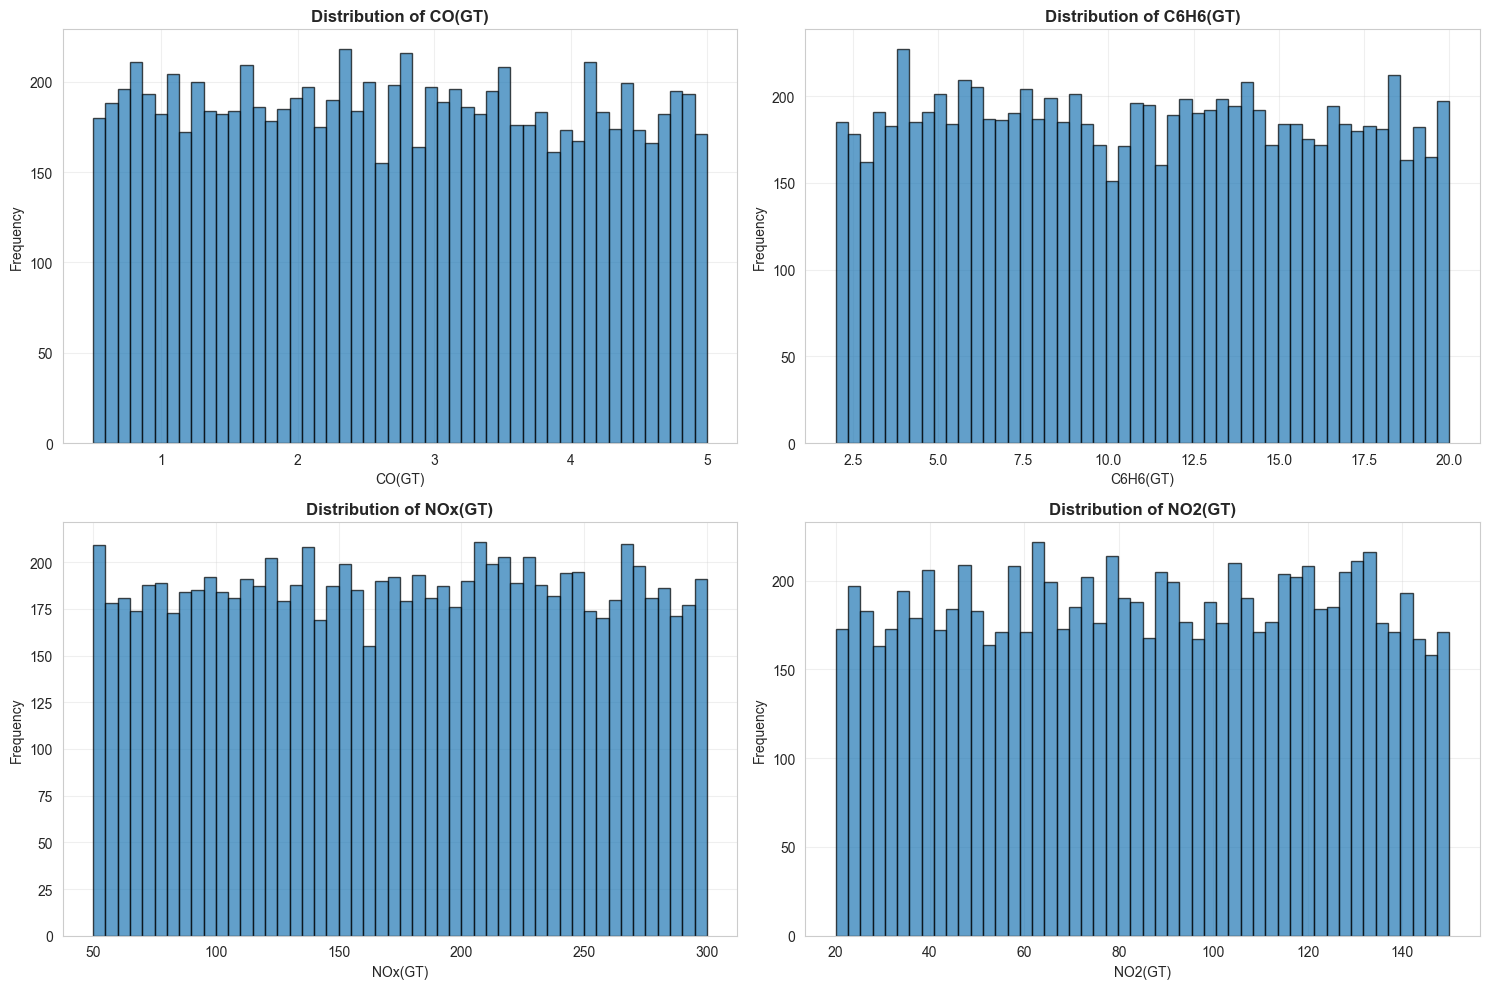

In [14]:
# Distribution plots for key pollutants
pollutants = ['CO(GT)', 'C6H6(GT)', 'NOx(GT)', 'NO2(GT)']

fig, axes = plt.subplots(2, 2, figsize=(15, 10))
axes = axes.ravel()

for idx, col in enumerate(pollutants):
    axes[idx].hist(df[col], bins=50, edgecolor='black', alpha=0.7)
    axes[idx].set_title(f'Distribution of {col}', fontsize=12, fontweight='bold')
    axes[idx].set_xlabel(col)
    axes[idx].set_ylabel('Frequency')
    axes[idx].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### 2.6 Correlation Analysis

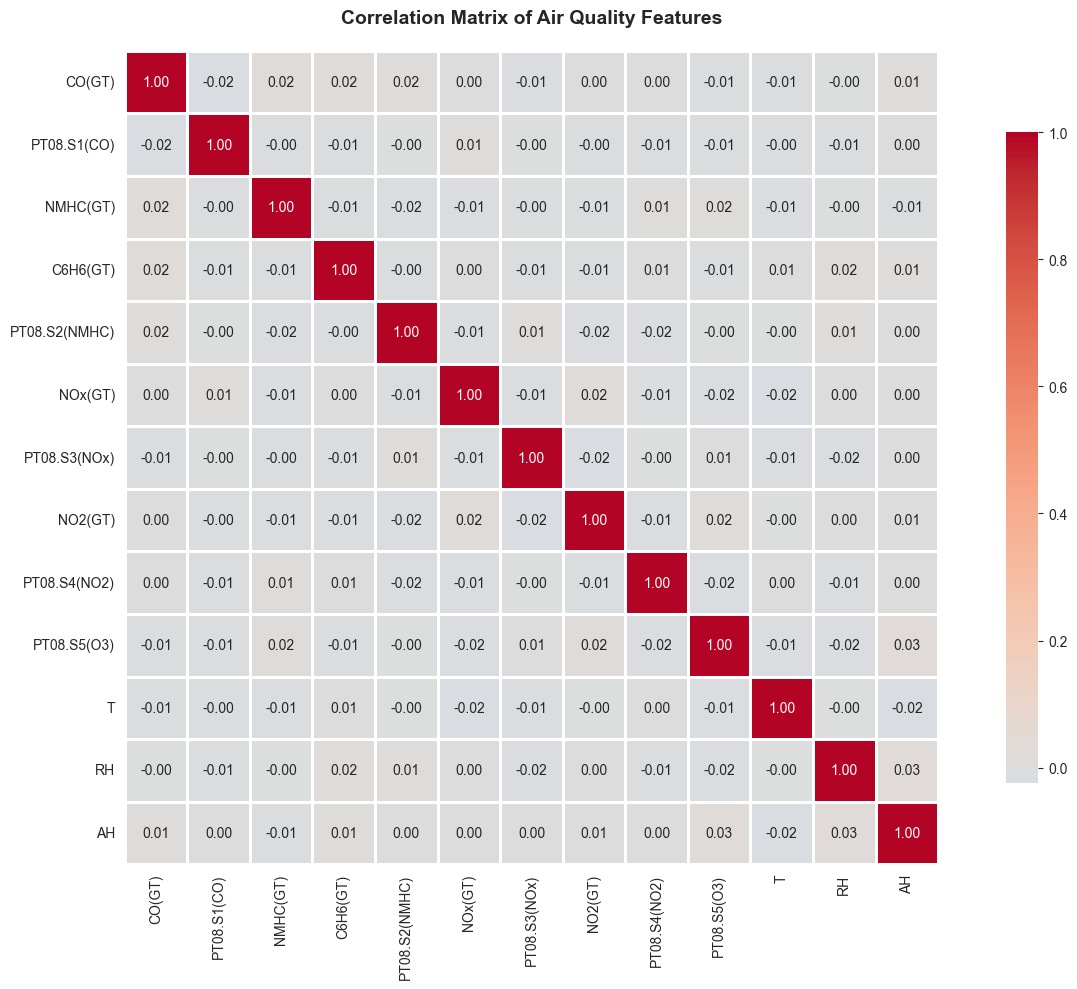

In [15]:
# Correlation matrix
numerical_cols = df.select_dtypes(include=[np.number]).columns
correlation_matrix = df[numerical_cols].corr()

# Plot correlation heatmap
plt.figure(figsize=(14, 10))
sns.heatmap(correlation_matrix, annot=True, fmt='.2f', cmap='coolwarm', 
            center=0, square=True, linewidths=1, cbar_kws={"shrink": 0.8})
plt.title('Correlation Matrix of Air Quality Features', fontsize=14, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

### 2.7 Temporal Analysis

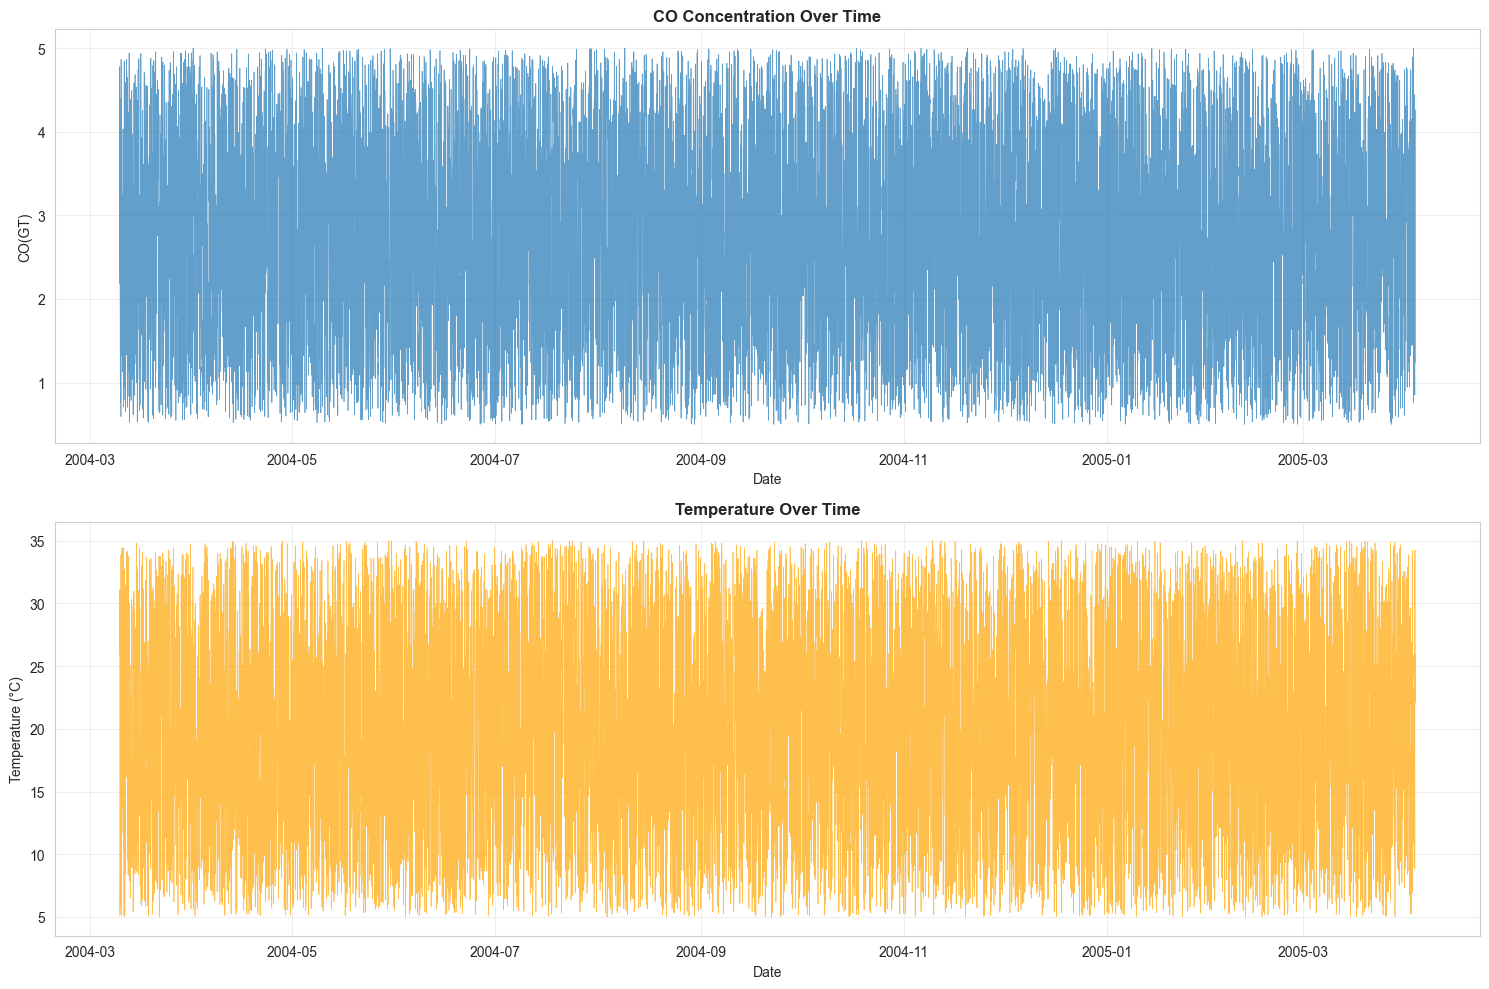

In [16]:
# Time series plot for key pollutants
if 'Date' in df.columns:
    df['Date'] = pd.to_datetime(df['Date'])
    
    fig, axes = plt.subplots(2, 1, figsize=(15, 10))
    
    # CO time series
    axes[0].plot(df['Date'], df['CO(GT)'], linewidth=0.5, alpha=0.7)
    axes[0].set_title('CO Concentration Over Time', fontsize=12, fontweight='bold')
    axes[0].set_xlabel('Date')
    axes[0].set_ylabel('CO(GT)')
    axes[0].grid(True, alpha=0.3)
    
    # Temperature time series
    axes[1].plot(df['Date'], df['T'], linewidth=0.5, alpha=0.7, color='orange')
    axes[1].set_title('Temperature Over Time', fontsize=12, fontweight='bold')
    axes[1].set_xlabel('Date')
    axes[1].set_ylabel('Temperature (°C)')
    axes[1].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()

### 2.8 Outlier Detection

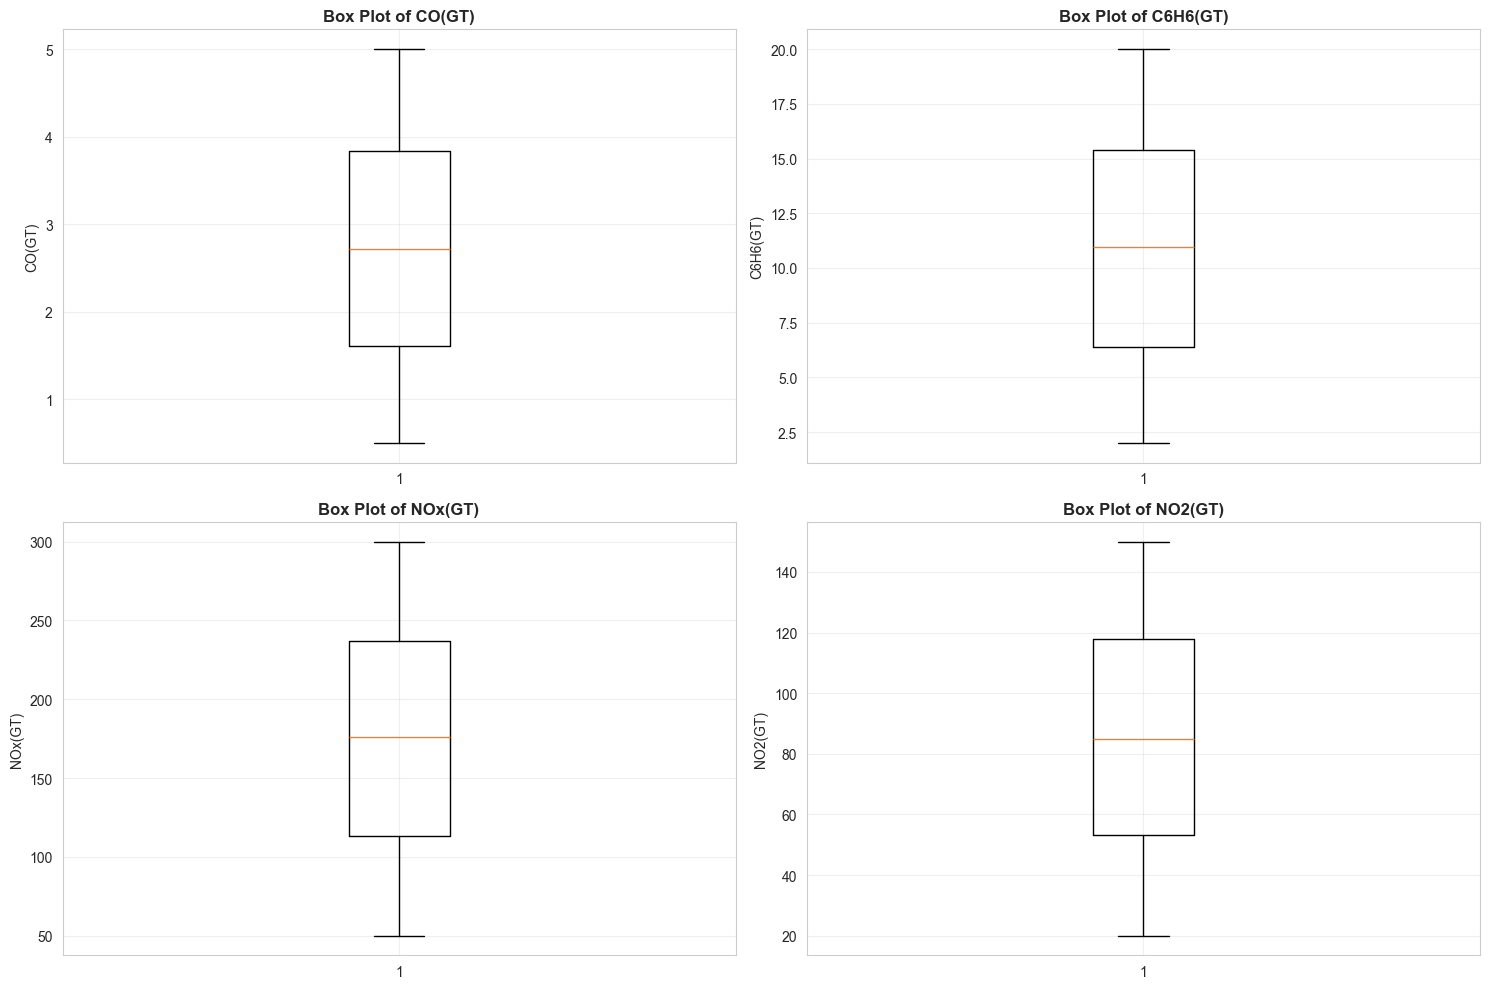

In [17]:
# Box plots for outlier detection
fig, axes = plt.subplots(2, 2, figsize=(15, 10))
axes = axes.ravel()

for idx, col in enumerate(pollutants):
    axes[idx].boxplot(df[col].dropna())
    axes[idx].set_title(f'Box Plot of {col}', fontsize=12, fontweight='bold')
    axes[idx].set_ylabel(col)
    axes[idx].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### 2.9 Statistical Tests

In [18]:
# Normality tests for key features
print("Normality Tests (Shapiro-Wilk):")
print("=" * 80)
for col in pollutants:
    sample = df[col].dropna().sample(min(5000, len(df[col].dropna())))  # Sample for large datasets
    stat, p_value = stats.shapiro(sample)
    print(f"{col:15} | Statistic: {stat:.4f} | p-value: {p_value:.4e} | Normal: {p_value > 0.05}")

Normality Tests (Shapiro-Wilk):
CO(GT)          | Statistic: 0.9553 | p-value: 1.2396e-36 | Normal: False
C6H6(GT)        | Statistic: 0.9520 | p-value: 1.1709e-37 | Normal: False
NOx(GT)         | Statistic: 0.9555 | p-value: 1.5038e-36 | Normal: False
NO2(GT)         | Statistic: 0.9563 | p-value: 2.7120e-36 | Normal: False


## 3. Results

*To be completed: Discuss your findings, including:*
- *Dataset characteristics and distributions*
- *Correlation patterns between pollutants and sensors*
- *Temporal patterns identified*
- *Outliers and anomalies detected*
- *Statistical significance of relationships*
- *Key insights about air quality patterns*

## 4. Conclusions

*To be completed: Summarize the main findings and their implications for the subsequent regression and classification tasks.*

## 5. References

*To be completed: Add references to:*
- *UCI Machine Learning Repository*
- *Relevant papers on air quality analysis*
- *Statistical methods used*